In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Keras IMDB dataset
from keras.datasets import imdb

In [3]:
# Load dataset (top 10,000 words)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


C:\Users\Shree\anaconda3\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [4]:
# Combine for EDA
data = np.concatenate((X_train, X_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

In [5]:
# -----------------------------
# Basic Info
# -----------------------------
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Example review:", X_train[0])
print("Label:", y_train[0])

Training shape: (25000,)
Test shape: (25000,)
Example review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32

In [6]:
# -----------------------------
# Vocabulary
# -----------------------------
word_index = imdb.get_word_index()
reverse_index = {value: key for key, value in word_index.items()}

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


In [7]:
# Decode sample review
decoded_review = " ".join([reverse_index.get(i - 3, "#") for i in X_train[0]])
print("\nDecoded Review:\n", decoded_review)


Decoded Review:
 # this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert # is an amazing actor and now the same being director # father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for # and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also # to the two little boy's that played the # of norman and paul they were just brilliant children are often left out of the # list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have 

In [8]:
# -----------------------------
# EDA
# -----------------------------
print("Categories:", np.unique(labels))
print("Unique words:", len(np.unique(np.hstack(data))))

lengths = [len(i) for i in data]
print("Average length:", np.mean(lengths))
print("Std deviation:", np.std(lengths))

Categories: [0 1]
Unique words: 9998
Average length: 234.75892
Std deviation: 172.91149458735703


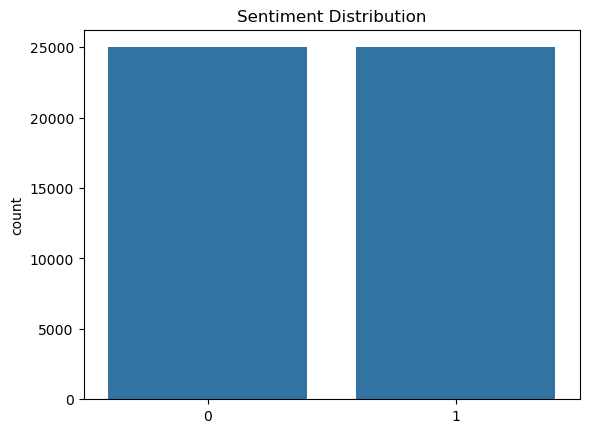

In [9]:
# Plot label distribution
sns.countplot(x=labels)
plt.title("Sentiment Distribution")
plt.show()

In [10]:
# -----------------------------
# Vectorization (One-hot)
# -----------------------------
def vectorize(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

data = vectorize(data)
labels = np.array(labels).astype("float32")

In [11]:
# -----------------------------
# Train-Test Split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 10000)
Test shape: (10000, 10000)


In [12]:
# -----------------------------
# Build Model
# -----------------------------
from keras import models, layers

model = models.Sequential()

In [13]:
# Input Layer
model.add(layers.Dense(50, activation="relu", input_shape=(10000,)))

C:\Users\Shree\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Hidden Layers
model.add(layers.Dropout(0.3))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(50, activation="relu"))

In [15]:
# Output Layer
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 50)                  │         500,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 505,201 (1.93 MB)

 Trainable params: 505,201 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# -----------------------------
# Early Stopping
# -----------------------------
import tensorflow as tf

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [18]:
# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=512,
    validation_data=(X_test, y_test),
    callbacks=[callback]
)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.8134 - loss: 0.4134 - val_accuracy: 0.8990 - val_loss: 0.2517
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9163 - loss: 0.2196 - val_accuracy: 0.9011 - val_loss: 0.2471
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9433 - loss: 0.1567 - val_accuracy: 0.8953 - val_loss: 0.2794
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9621 - loss: 0.1134 - val_accuracy: 0.8906 - val_loss: 0.3102
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9748 - loss: 0.0745 - val_accuracy: 0.8898 - val_loss: 0.3855


In [19]:
# -----------------------------
# Evaluation
# -----------------------------
score = model.evaluate(X_test, y_test)
print("\nTest Loss:", score[0])
print("Test Accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9011 - loss: 0.2471

Test Loss: 0.24711491167545319
Test Accuracy: 0.9010999798774719


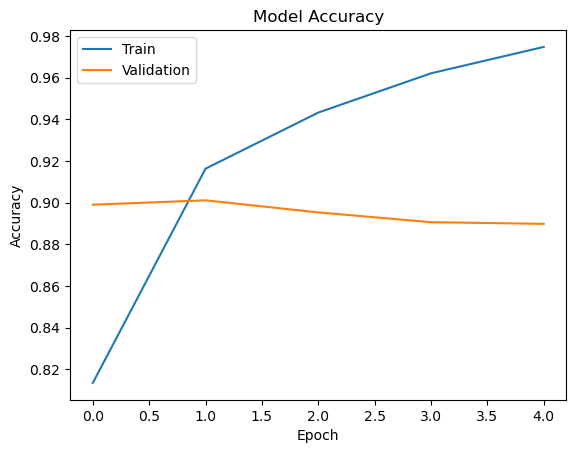

In [20]:
# -----------------------------
# Accuracy Plot
# -----------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

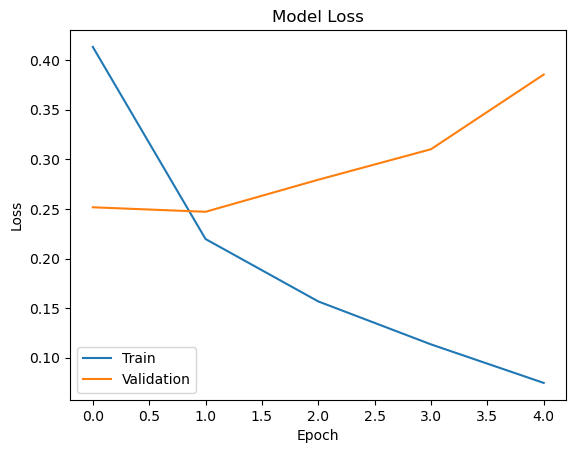

In [21]:
# -----------------------------
# Loss Plot
# -----------------------------
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()